# TEC Minute-wise Maximum Aggregation

This notebook reads TEC CSV files from folders `iisc1290_TECU` to `iisc1690_TECU`, combines all satellites (`G01_TEC.csv` to `G32_TEC.csv`) in each folder, computes the **highest TEC value for each minute**, and writes one output CSV per folder into `sortedDataSet`.

**Output format:**
- Column 1: `Time(UTC)` as `DD-MM-YY HH:MM`
- Column 2: `TEC(TECU)` as minute-wise maximum

In [1]:
from pathlib import Path
from datetime import datetime
import csv
import re
 
# Update if your base path changes
BASE_DIR = Path(r"D:\ProjectMentor\TEC_data")
OUTPUT_DIR = BASE_DIR / "sortedDataSet"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
print(f"Base directory : {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Base directory : D:\ProjectMentor\TEC_data
Output directory: D:\ProjectMentor\TEC_data\sortedDataSet


In [2]:
# ── Discover folders in range iisc1290_TECU … iisc1690_TECU ──────────────────
folder_pattern = re.compile(r"^iisc(\d{4})_TECU$")
source_folders = []
 
for p in BASE_DIR.iterdir():
    if not p.is_dir():
        continue
    m = folder_pattern.match(p.name)
    if not m:
        continue
    n = int(m.group(1))
    if 1290 <= n <= 1690:
        source_folders.append((n, p))
 
source_folders.sort(key=lambda x: x[0])
print(f"Folders found in range: {len(source_folders)}")
 
# ── Process each folder ───────────────────────────────────────────────────────
written_files = 0
 
for _, folder_path in source_folders:
    minute_max: dict = {}
 
    # Read G01_TEC.csv to G32_TEC.csv
    for sat_idx in range(1, 33):
        csv_name = f"G{sat_idx:02d}_TEC.csv"
        csv_path = folder_path / csv_name
 
        if not csv_path.exists():
            continue
 
        with csv_path.open("r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                time_text = (row.get("Time (UTC)") or "").strip()
                tec_text  = (row.get("TEC (TECU)")  or "").strip()
 
                if not time_text or not tec_text:
                    continue
 
                try:
                    dt  = datetime.strptime(time_text, "%Y-%m-%d %H:%M:%S")
                    tec = float(tec_text)
                except ValueError:
                    continue
 
                # Round down to the minute by zeroing seconds
                minute_dt = dt.replace(second=0)
                prev = minute_max.get(minute_dt)
                if prev is None or tec > prev:
                    minute_max[minute_dt] = tec
 
    # ── Write one output CSV per folder ──────────────────────────────────────
    output_csv = OUTPUT_DIR / f"{folder_path.name}_sorted.csv"
 
    with output_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["Time(UTC)", "TEC(TECU)"])
        for minute_dt in sorted(minute_max.keys()):
            writer.writerow([
                minute_dt.strftime("%d-%m-%y %H:%M"),
                f"{minute_max[minute_dt]:.6f}",
            ])
 
    written_files += 1
 
print(f"CSV files written: {written_files}")
print(f"Saved in        : {OUTPUT_DIR}")

Folders found in range: 41
CSV files written: 41
Saved in        : D:\ProjectMentor\TEC_data\sortedDataSet


In [3]:
# ── Quick sanity-check: print first 6 lines of the first output file ─────────
sample_file = OUTPUT_DIR / "iisc1290_TECU_sorted.csv"
 
if sample_file.exists():
    with sample_file.open("r", newline="", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5:
                break
else:
    print(f"Sample file not found: {sample_file}")

Time(UTC),TEC(TECU)
09-05-23 00:00,42.390972
09-05-23 00:01,51.206161
09-05-23 00:02,32.852289
09-05-23 00:03,34.870453
09-05-23 00:04,39.373245


## TEC Day-Ahead LSTM Prediction
```
Data layout (41 sorted CSV files):
  Day  1 → iisc1290_TECU_sorted.csv
  Day  2 → iisc1300_TECU_sorted.csv
  ...
  Day 30 → iisc1580_TECU_sorted.csv   ← last training day
  Day 31 → iisc1590_TECU_sorted.csv   ← first validation day
  ...
  Day 41 → iisc1690_TECU_sorted.csv   ← prediction target

Split strategy (next-day prediction):
  Training   : input days  1–29  → target days  2–30   (29 pairs)
  Validation : input days 30–40  → target days 31–41   (11 pairs)
  Forecast   : input  day 40     → predict day  41

Each day = 1440-minute sequence (00:00 – 23:59 UTC).
```

In [2]:
import numpy as np
import csv
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
 
# ── TensorFlow ────────────────────────────────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, LSTM, Dense, TimeDistributed
except Exception as e:
    raise ImportError(
        "TensorFlow is required. Install with: pip install tensorflow"
    ) from e
 
# ── Paths ─────────────────────────────────────────────────────────────────────
SORTED_DIR = Path(r"D:\ProjectMentor\TEC_data\sortedDataSet")
if not SORTED_DIR.exists():
    raise FileNotFoundError(f"Sorted dataset folder not found: {SORTED_DIR}")
 
all_csv = sorted(SORTED_DIR.glob("*_sorted.csv"))
if len(all_csv) < 41:
    raise ValueError(f"Need at least 41 sorted CSV files, found {len(all_csv)}")

# Use exactly 41 files: days 1–41
# Day 1  = iisc1290_TECU_sorted  (index 0)
# Day 30 = iisc1580_TECU_sorted  (index 29)  ← last training day
# Day 31 = iisc1590_TECU_sorted  (index 30)  ← first validation day
# Day 41 = iisc1690_TECU_sorted  (index 40)  ← prediction target
print(f"Total sorted CSV files found : {len(all_csv)}")
print(f"Day  1 (train start) : {all_csv[0].name}")   # iisc1290_TECU_sorted
print(f"Day 30 (train end)   : {all_csv[29].name}")  # iisc1580_TECU_sorted
print(f"Day 31 (val start)   : {all_csv[30].name}")  # iisc1590_TECU_sorted
print(f"Day 41 (val end/tgt) : {all_csv[40].name}")  # iisc1690_TECU_sorted

Total sorted CSV files found : 41
Day  1 (train start) : iisc1290_TECU_sorted.csv
Day 30 (train end)   : iisc1580_TECU_sorted.csv
Day 31 (val start)   : iisc1590_TECU_sorted.csv
Day 41 (val end/tgt) : iisc1690_TECU_sorted.csv


## Build aligned day-wise matrix (days × minutes)

Loads each daily CSV, aligns values by minute (`HH:MM`), and builds a matrix of shape `(41, 1440)`.

In [5]:
minute_labels = [f"{h:02d}:{m:02d}" for h in range(24) for m in range(60)]
minute_index  = {t: i for i, t in enumerate(minute_labels)}
 
 
def load_day_vector(csv_path: Path) -> np.ndarray:
    """Load one sorted CSV → float32 array of length 1440."""
    vec = np.full(1440, np.nan, dtype=np.float32)
    with csv_path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            t = (row.get("Time(UTC)") or "").strip()
            v = (row.get("TEC(TECU)")  or "").strip()
            if not t or not v:
                continue
            try:
                dt  = datetime.strptime(t, "%d-%m-%y %H:%M")
                tec = float(v)
            except ValueError:
                continue
            key = dt.strftime("%H:%M")
            idx = minute_index.get(key)
            if idx is not None:
                vec[idx] = tec
 
    # Fill gaps with linear interpolation
    if np.isnan(vec).any():
        x     = np.arange(len(vec))
        valid = ~np.isnan(vec)
        if valid.sum() == 0:
            raise ValueError(f"No usable TEC data in: {csv_path.name}")
        vec = np.interp(x, x[valid], vec[valid]).astype(np.float32)
 
    return vec
 
 
# Load exactly 41 days (files 0..40 → days 1..41)
daily_files  = all_csv[:41]
daily_matrix = np.stack([load_day_vector(p) for p in daily_files], axis=0)
 
print(f"Daily matrix shape (days × minutes): {daily_matrix.shape}")
print(f"Day  1 file : {daily_files[0].name}")
print(f"Day 41 file : {daily_files[40].name}")

Daily matrix shape (days × minutes): (41, 1440)
Day  1 file : iisc1290_TECU_sorted.csv
Day 41 file : iisc1690_TECU_sorted.csv


## Supervised pairs and normalisation

```
Pair index k  →  input = day k+1,  target = day k+2   (1-based)

Training   : input days  1–29  → target days  2–30   k = 0..28  (29 pairs)
Validation : input days 30–40  → target days 31–41   k = 29..39 (11 pairs)

Train covers files  iisc1290_sorted … iisc1580_sorted
Val   covers files  iisc1580_sorted … iisc1690_sorted
```

In [6]:
# ── Build input/target pairs ──────────────────────────────────────────────────
# X_all[k] = day k+1  (0-based index k,   days 1..40)
# y_all[k] = day k+2  (0-based index k+1, days 2..41)
X_all = daily_matrix[:-1]   # shape (40, 1440) — days 1..40
y_all = daily_matrix[1:]    # shape (40, 1440) — days 2..41

# target day number (1-based) for each pair
target_day_num = np.arange(2, 42)   # 2..41,  length 40

# Training   : target days  2–30  →  29 pairs  (input days  1–29)
# Validation : target days 31–41  →  11 pairs  (input days 30–40)
train_mask = (target_day_num >= 2)  & (target_day_num <= 30)   # 29 pairs
val_mask   = (target_day_num >= 31) & (target_day_num <= 41)   # 11 pairs

X_train_raw, y_train_raw = X_all[train_mask], y_all[train_mask]
X_val_raw,   y_val_raw   = X_all[val_mask],   y_all[val_mask]

print(f"Train samples : {X_train_raw.shape[0]}  "
      f"(input days 1–29  → target days 2–30)")
print(f"Val   samples : {X_val_raw.shape[0]}  "
      f"(input days 30–40 → target days 31–41)")

# ── Normalise using TRAINING statistics only ──────────────────────────────────
x_mean = float(X_train_raw.mean())
x_std  = float(X_train_raw.std())  + 1e-8
y_mean = float(y_train_raw.mean())
y_std  = float(y_train_raw.std())  + 1e-8

X_train = ((X_train_raw - x_mean) / x_std)[..., np.newaxis]   # (29, 1440, 1)
y_train = ((y_train_raw - y_mean) / y_std)[..., np.newaxis]
X_val   = ((X_val_raw   - x_mean) / x_std)[..., np.newaxis]   # (11, 1440, 1)
y_val   = ((y_val_raw   - y_mean) / y_std)[..., np.newaxis]

print(f"\nX_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"\nNormalisation stats  x_mean={x_mean:.4f}  x_std={x_std:.4f}")
print(f"                     y_mean={y_mean:.4f}  y_std={y_std:.4f}")

Train samples : 29  (input days 1–29  → target days 2–30)
Val   samples : 11  (input days 30–40 → target days 31–41)

X_train : (29, 1440, 1)  y_train : (29, 1440, 1)
X_val   : (11, 1440, 1)    y_val   : (11, 1440, 1)

Normalisation stats  x_mean=87.8867  x_std=45.8948
                     y_mean=86.9246  y_std=45.3013


## Train LSTM

In [7]:
tf.random.set_seed(42)
np.random.seed(42)
 
lstm_model = Sequential([
    Input(shape=(1440, 1)),
    LSTM(64, return_sequences=True),
    LSTM(32, return_sequences=True),
    TimeDistributed(Dense(1)),
], name="LSTM_TEC_Model")

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()
 
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=4,
    verbose=1,
)

Model: "LSTM_TEC_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1440, 64)            │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 1440, 32)            │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 1440, 1)             │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - loss: 0.7023 - val_loss: 0.1916
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 917ms/step - loss: 0.1722 - val_loss: 0.2038
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 920ms/step - loss: 0.1606 - val_loss: 0.1239
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 928ms/step - loss: 0.1461 - val_loss: 0.1323
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 937ms/step - loss: 0.1385 - val_loss: 0.1276
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 923ms/step - loss: 0.1341 - val_loss: 0.1261
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 935ms/step - loss: 0.1322 - val_loss: 0.1223
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 924ms/step - loss: 0.1322 - val_loss: 0.1231
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 909ms/step - loss: 0.1310 - val_loss: 0.1227
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 926ms/step - loss: 0.1304 - val_loss: 0.1209
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 926ms/step - loss: 0.1302 - val_loss: 0.1207
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 913ms/step - loss: 0.1298 - val_loss

## LSTM — Training vs Validation Loss

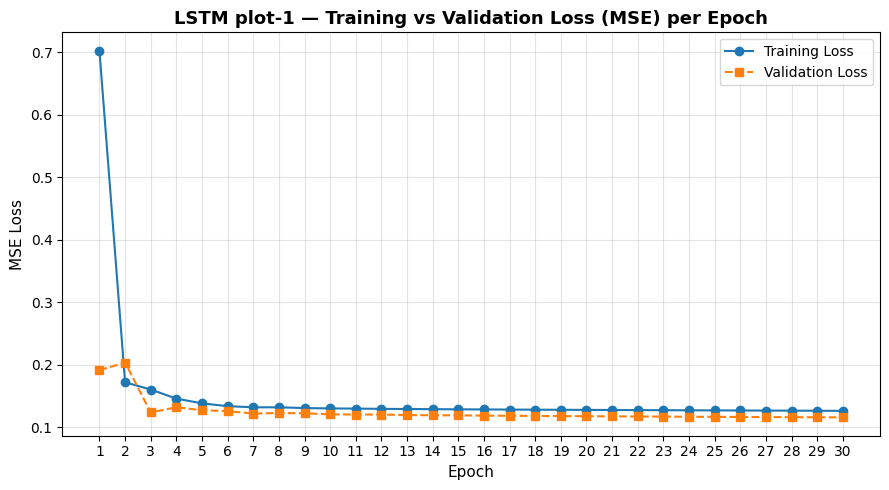

Final train loss : 0.126558
Final val   loss : 0.116104


In [8]:
epochs_range = range(1, len(lstm_history.history["loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, lstm_history.history["loss"],
         marker="o", linewidth=1.5, label="Training Loss")
plt.plot(epochs_range, lstm_history.history["val_loss"],
         marker="s", linewidth=1.5, linestyle="--", label="Validation Loss")
plt.title("LSTM plot-1 — Training vs Validation Loss (MSE) per Epoch",
          fontsize=13, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("MSE Loss", fontsize=11)
plt.xticks(epochs_range)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

print(f"Final train loss : {lstm_history.history['loss'][-1]:.6f}")
print(f"Final val   loss : {lstm_history.history['val_loss'][-1]:.6f}")

## LSTM — Predict Day 41 (from Day 40) and Plot vs Actual

- **Input**  : Day 40 TEC sequence (`iisc1680_TECU_sorted`)  
- **Target** : Day 41 TEC sequence (`iisc1690_TECU_sorted`)

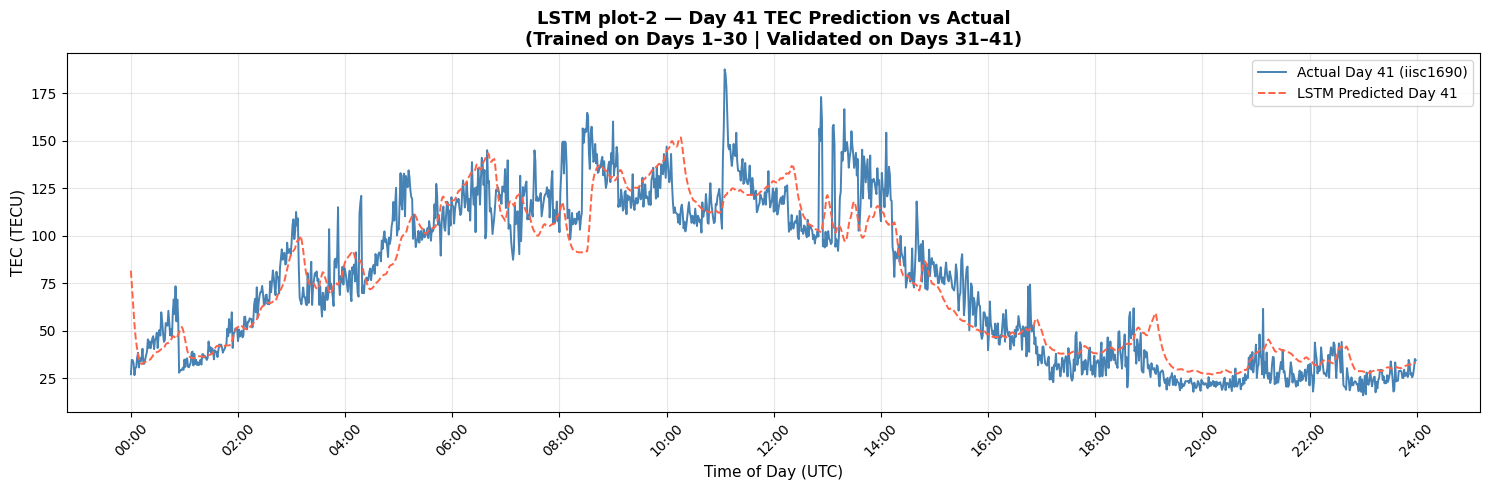

LSTM  Day-41 RMSE : 15.5976 TECU
LSTM  Day-41 MAE  : 11.3995 TECU


In [9]:
# Day 40 is at 0-based index 39; Day 41 is at index 40
day40_raw = daily_matrix[39]   # input to model
actual41  = daily_matrix[40]   # ground truth

day40_in      = ((day40_raw - x_mean) / x_std)[np.newaxis, ..., np.newaxis]  # (1, 1440, 1)
pred41_norm   = lstm_model.predict(day40_in, verbose=0)[0, :, 0]             # (1440,)
lstm_pred41   = pred41_norm * y_std + y_mean

minutes = np.arange(1440)
tick_pos   = np.arange(0, 1441, 120)
tick_labels = [f"{h:02d}:00" for h in range(0, 25, 2)]

plt.figure(figsize=(15, 5))
plt.plot(minutes, actual41,   color="steelblue",  linewidth=1.4,
         label="Actual Day 41 (iisc1690)")
plt.plot(minutes, lstm_pred41, color="tomato", linewidth=1.4, linestyle="--",
         label="LSTM Predicted Day 41")
plt.title("LSTM plot-2 — Day 41 TEC Prediction vs Actual\n"
          "(Trained on Days 1–30 | Validated on Days 31–41)",
          fontsize=13, fontweight="bold")
plt.xlabel("Time of Day (UTC)", fontsize=11)
plt.ylabel("TEC (TECU)", fontsize=11)
plt.xticks(ticks=tick_pos, labels=tick_labels, rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lstm_rmse = float(np.sqrt(np.mean((lstm_pred41 - actual41) ** 2)))
lstm_mae  = float(np.mean(np.abs(lstm_pred41 - actual41)))
print(f"LSTM  Day-41 RMSE : {lstm_rmse:.4f} TECU")
print(f"LSTM  Day-41 MAE  : {lstm_mae:.4f} TECU")

---
## Transformer-based Sequence-to-Sequence Model for TEC Forecasting

This section replaces the LSTM architecture with a Transformer encoder model.

### Key Differences from LSTM:
- Uses self-attention instead of recurrence
- Captures long-range dependencies across 1440 timesteps
- Processes sequences in parallel
- Uses positional encoding to retain temporal order

### Architecture:
- Input Projection (Dense) → d_model dimensions
- Sinusoidal Positional Encoding
- Stacked Transformer Encoder Layers (Multi-Head Attention + FFN)
- TimeDistributed Output Projection

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ---- Positional Encoding ------------------------------------------------
def positional_encoding(length, d_model):
    positions = tf.range(length, dtype=tf.float32)[:, tf.newaxis]
    dims      = tf.range(d_model,  dtype=tf.float32)[tf.newaxis, :]
    angle_rates = 1 / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(d_model, tf.float32))
    angle_rads  = positions * angle_rates
    sines   = tf.sin(angle_rads[:, 0::2])
    cosines = tf.cos(angle_rads[:, 1::2])
    pos_encoding = tf.concat([sines, cosines], axis=-1)   # (length, d_model)
    return pos_encoding[tf.newaxis, ...]                   # (1, length, d_model)

# ---- Transformer Encoder Block ------------------------------------------
def transformer_encoder(x, head_size, num_heads, ff_dim, dropout=0.1):
    # Multi-head self-attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    attn = layers.Dropout(dropout)(attn)
    x    = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    # Feed-forward network
    ffn  = layers.Dense(ff_dim, activation="relu")(x)
    ffn  = layers.Dense(x.shape[-1])(ffn)
    ffn  = layers.Dropout(dropout)(ffn)
    return layers.LayerNormalization(epsilon=1e-6)(x + ffn)

# ---- Model Builder -------------------------------------------------------
def build_transformer(
    input_shape=(1440, 1),
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_layers=3,
    dropout=0.1,
):
    inputs = layers.Input(shape=input_shape)
    x      = layers.Dense(d_model)(inputs)          # project to d_model
    x      = x + positional_encoding(1440, d_model) # add sinusoidal PE
    for _ in range(num_layers):
        x  = transformer_encoder(x, d_model, num_heads, ff_dim, dropout)
    outputs = layers.Dense(1)(x)                    # project back to 1
    return Model(inputs, outputs, name="Transformer_TEC_Model")

print("Transformer architecture helpers defined.")

Transformer architecture helpers defined.


## Train Transformer

Uses the **same** train/val splits and normalisation statistics as the LSTM.

In [11]:
tf.random.set_seed(42)
np.random.seed(42)

transformer_model = build_transformer()
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
)
transformer_model.summary()

# X_train, y_train, X_val, y_val are already defined in the LSTM section above
transformer_history = transformer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=4,
    verbose=1,
)

Model: "Transformer_TEC_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 1440, 1)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 1440, 64)          │             128 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 1440, 64)          │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 1440, 64)          │          66,368 │ add[0][0], add[0][0]       │
│ (MultiHeadAttention)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 1440, 64)          │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 1440, 64)          │               0 │ add[0][0], dropout_1[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 1440, 64)          │             128 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1440, 128)         │           8,320 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1440, 64)          │           8,256 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 1440, 64)          │               0 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 1440, 64)          │               0 │ layer_normalization[0][0], │
│                               │                           │                 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 1440, 64)          │             128 │ add_2[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 1440, 64)          │          66,368 │ layer_normalization_1[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 1440, 64)          │               0 │ multi_head_attention_1[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_3 (Add)                   │ (None, 1440, 64)          │               

 Total params: 249,793 (975.75 KB)

 Trainable params: 249,793 (975.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 1.5830 - val_loss: 1.1195
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.5634 - val_loss: 0.1890
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.2886 - val_loss: 0.2162
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.2308 - val_loss: 0.1323
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.2010 - val_loss: 0.1326
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.1825 - val_loss: 0.1473
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.1759 - val_loss: 0.1185
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.1620 - val_loss: 0.1351
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.1607 - val_loss: 0.1208
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.1549 - val_loss: 0.1173
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.1507 - val_loss: 0.1220
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.1484 - val_loss: 0.1199
Epoch 13/30
8

## Transformer — Training vs Validation Loss

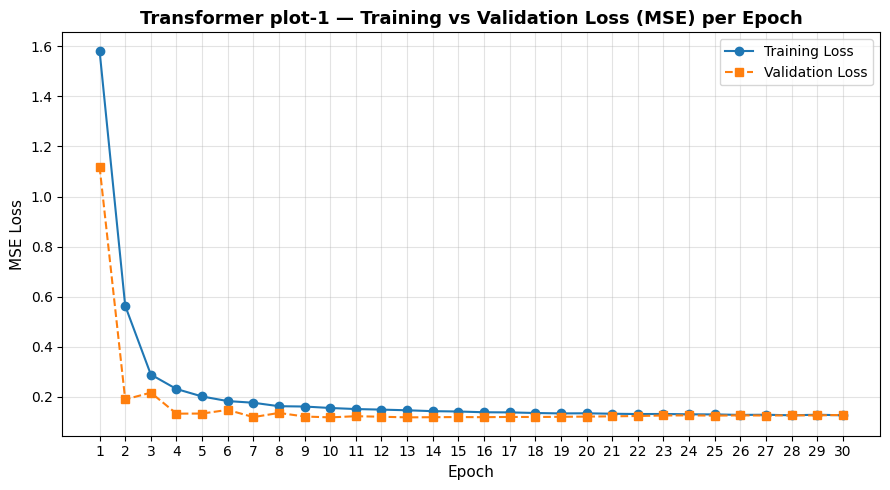

Final train loss : 0.125741
Final val   loss : 0.127072


In [12]:
epochs_range = range(1, len(transformer_history.history["loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, transformer_history.history["loss"],
         marker="o", linewidth=1.5, label="Training Loss")
plt.plot(epochs_range, transformer_history.history["val_loss"],
         marker="s", linewidth=1.5, linestyle="--", label="Validation Loss")
plt.title("Transformer plot-1 — Training vs Validation Loss (MSE) per Epoch",
          fontsize=13, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("MSE Loss", fontsize=11)
plt.xticks(epochs_range)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

print(f"Final train loss : {transformer_history.history['loss'][-1]:.6f}")
print(f"Final val   loss : {transformer_history.history['val_loss'][-1]:.6f}")

## Transformer — Predict Day 41 (from Day 40) and Plot vs Actual

- **Input**  : Day 40 TEC sequence (`iisc1680_TECU_sorted`)  
- **Target** : Day 41 TEC sequence (`iisc1690_TECU_sorted`)

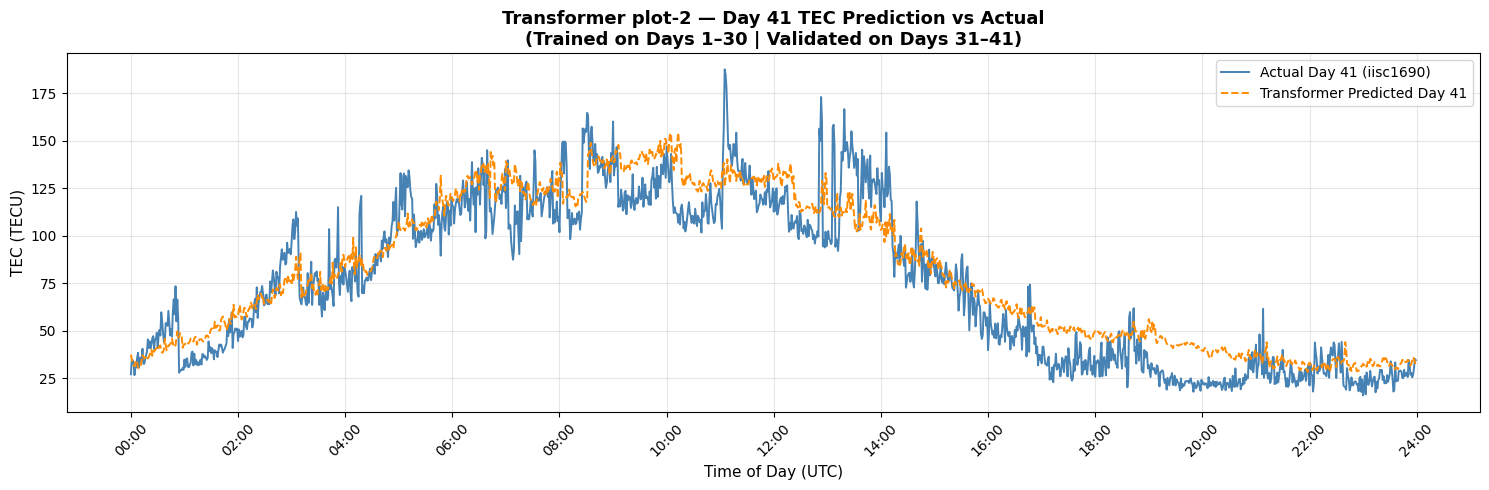

Transformer Day-41 RMSE : 15.3717 TECU
Transformer Day-41 MAE  : 12.3875 TECU


In [13]:
# Same input / actual arrays as LSTM (day40_raw, actual41 defined earlier)
day40_in_t        = ((day40_raw - x_mean) / x_std)[np.newaxis, ..., np.newaxis]  # (1, 1440, 1)
trans_pred41_norm = transformer_model.predict(day40_in_t, verbose=0)[0, :, 0]    # (1440,)
trans_pred41      = trans_pred41_norm * y_std + y_mean

tick_pos    = np.arange(0, 1441, 120)
tick_labels = [f"{h:02d}:00" for h in range(0, 25, 2)]

plt.figure(figsize=(15, 5))
plt.plot(minutes, actual41,     color="steelblue",  linewidth=1.4,
         label="Actual Day 41 (iisc1690)")
plt.plot(minutes, trans_pred41, color="darkorange", linewidth=1.4, linestyle="--",
         label="Transformer Predicted Day 41")
plt.title("Transformer plot-2 — Day 41 TEC Prediction vs Actual\n"
          "(Trained on Days 1–30 | Validated on Days 31–41)",
          fontsize=13, fontweight="bold")
plt.xlabel("Time of Day (UTC)", fontsize=11)
plt.ylabel("TEC (TECU)", fontsize=11)
plt.xticks(ticks=tick_pos, labels=tick_labels, rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

trans_rmse = float(np.sqrt(np.mean((trans_pred41 - actual41) ** 2)))
trans_mae  = float(np.mean(np.abs(trans_pred41 - actual41)))
print(f"Transformer Day-41 RMSE : {trans_rmse:.4f} TECU")
print(f"Transformer Day-41 MAE  : {trans_mae:.4f} TECU")

## Model Comparison Summary

In [14]:
print("=" * 45)
print(f"{'Model':<15} {'RMSE (TECU)':>12} {'MAE (TECU)':>12}")
print("-" * 45)
print(f"{'LSTM':<15} {lstm_rmse:>12.4f} {lstm_mae:>12.4f}")
print(f"{'Transformer':<15} {trans_rmse:>12.4f} {trans_mae:>12.4f}")
print("=" * 45)

Model            RMSE (TECU)   MAE (TECU)
---------------------------------------------
LSTM                 15.5976      11.3995
Transformer          15.3717      12.3875
